In [75]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib


import sys
sys.path.append('..')
import plot_settings
plot_settings.apply()
import sim_PyBaMM
importlib.reload(sim_PyBaMM);
import exp_pybamm_ver4
importlib.reload(exp_pybamm_ver4);

In [2]:
T_HORIZON = 3600.0          # [s]  total simulation horizon
T = 1000            # number of time steps
DT = T_HORIZON / (T - 1)   # 3.6036s — fixed for all sims

In [82]:
def get_vals_DC(I0, T=T, t_horizon=T_HORIZON):

    sol, model, param = sim_PyBaMM.simulate_DC1(I0, T, t_horizon)   # simulate with t_eval = np.linspace(0, t_horizon, T)

    t_end = sol["Time [s]"].entries[-1]
    t_fixed = np.linspace(0, t_horizon, T)    # fixed 'physical' grid
    valid = t_fixed <= t_end  # boolean, length T # Valid mask: where simulation was still running
    t_query = np.clip(t_fixed, 0, t_end)     # Observe only up to t_end, fill rest with NaN or last value
    # print(t_fixed[-1], t_query.shape, t_end, valid[-1])

    cn = sol.observe(model.variables["X-averaged negative particle concentration [mol.m-3]"])(t_query)[-1, :]
    cp = sol.observe(model.variables["X-averaged positive particle concentration [mol.m-3]"])(t_query)[-1, :]
    I = sol.observe(model.variables["Current [A]"])(t_query)
    V = sol.observe(model.variables["Terminal voltage [V]"])(t_query)

    return t_fixed, DT, V, I, cn, cp, valid  # valid is your loss mask

def get_vals_pulse(T=T, t_horizon=T_HORIZON):
    sol, model, t_eval, param = exp_pybamm_ver4.generate_data(t_horizon, DT, RNG=None)   # simulate with t_eval = np.linspace(0, t_horizon, T)

    t_end = sol["Time [s]"].entries[-1]
    t_fixed = np.linspace(0, t_horizon, T)    # fixed 'physical' grid
    valid = t_fixed <= t_end  # boolean, length T # Valid mask: where simulation was still running
    t_query = np.clip(t_fixed, 0, t_end)     # Observe only up to t_end, fill rest with NaN or last value
    # print(t_fixed[-1], t_query.shape, t_end, valid[-1])

    cn = sol.observe(model.variables["X-averaged negative particle concentration [mol.m-3]"])(t_query)[-1, :]
    cp = sol.observe(model.variables["X-averaged positive particle concentration [mol.m-3]"])(t_query)[-1, :]
    I = sol.observe(model.variables["Current [A]"])(t_query)
    V = sol.observe(model.variables["Terminal voltage [V]"])(t_query)

    return t_fixed, DT, V, I, cn, cp, valid

def get_vals_GRF(T=T, t_horizon=T_HORIZON):
    sol, model, param = sim_PyBaMM.simulate_GRF(T, t_horizon)   # simulate with t_eval = np.linspace(0, t_horizon, T)

    t_end = sol["Time [s]"].entries[-1]
    t_fixed = np.linspace(0, t_horizon, T)    # fixed 'physical' grid
    valid = t_fixed <= t_end  # boolean, length T # Valid mask: where simulation was still running
    t_query = np.clip(t_fixed, 0, t_end)     # Observe only up to t_end, fill rest with NaN or last value
    # print(t_fixed[-1], t_query.shape, t_end, valid[-1])

    cn = sol.observe(model.variables["X-averaged negative particle concentration [mol.m-3]"])(t_query)[-1, :]
    cp = sol.observe(model.variables["X-averaged positive particle concentration [mol.m-3]"])(t_query)[-1, :]
    I = sol.observe(model.variables["Current [A]"])(t_query)
    V = sol.observe(model.variables["Terminal voltage [V]"])(t_query)

    return t_fixed, DT, V, I, cn, cp, valid  # valid is your loss mask

def gen_data_I_c(B, T=T, currents='DC', I_low=0.25, I_high=1.0, seed=None):
    """
    Generates B trajectories of length T at random constant currents.
    Computes c_dot via finite difference / dt.
    """
    rng = np.random.default_rng(seed)

    V = np.zeros((B, T, 1))
    I = np.zeros((B, T, 1))
    dI = np.zeros((B, T, 1))
    cn = np.zeros((B, T, 1))
    cp = np.zeros((B, T, 1))
    cn_dot = np.zeros((B, T, 1))
    cp_dot = np.zeros((B, T, 1))
    valid = np.zeros((B, T), dtype=bool)

    for i in trange(B):
        if currents == 'DC':
            I0 = float(rng.uniform(I_low, I_high))
            t, dt, V_i, I_i, cn_i, cp_i, valid_i = get_vals_DC(I0, T=T, t_horizon=T_HORIZON)
        elif currents == 'pulse':
            t, dt, V_i, I_i, cn_i, cp_i, valid_i = get_vals_pulse(T=T, t_horizon=T_HORIZON)
            pass
        elif currents == 'GRF':
            I0 = float(rng.uniform(I_low, I_high))
            t, dt, V_i, I_i, cn_i, cp_i, valid_i = get_vals_GRF(T=T, t_horizon=T_HORIZON)
        
        V[i, :, 0] = V_i
        I[i, :, 0] = I_i
        cn[i, :, 0] = cn_i
        cp[i, :, 0] = cp_i
        valid[i, :] = valid_i

        # dI(t): backward difference,  dI[0] = 0
        dI[i, 1:, 0] = np.diff(I_i)
        dI[i, 0,  0] = 0.0

        # Proper time derivative (backward/forward diff)
        cn_dot[i, :-1, 0] = np.diff(cn_i) / dt
        cp_dot[i, :-1, 0] = np.diff(cp_i) / dt

        # pad last entry
        cn_dot[i, -1, 0] = cn_dot[i, -2, 0]
        cp_dot[i, -1, 0] = cp_dot[i, -2, 0]

    return I, dI, V, cn, cn_dot, cp, cp_dot, valid

In [ ]:
B = 200
# I, dI, V, cn, cn_dot, cp, cp_dot, valid = gen_data_I_c(B, T, currents='pulse')

100%|██████████| 200/200 [00:40<00:00,  4.91it/s]


In [181]:
# np.savez('data_c_pulse.npz', I=I, dI=dI, V=V, cn=cn, cn_dot=cn_dot, cp=cp, cp_dot=cp_dot, valid=valid)

def load_data(path):
    data = np.load(path)
    return data['I'], data['dI'], data['V'], data['cn'], data['cn_dot'], data['cp'], data['cp_dot'], data['valid']

# I, dI, V, cn, cn_dot, cp, cp_dot, valid = load_data('data_c_GRFI.npz')
# I, dI, V, cn, cn_dot, cp, cp_dot, valid = load_data('t=5e3_GRF_data_c_dot.npz')
I, dI, V, cn, cn_dot, cp, cp_dot, valid = load_data('data_c_pulse.npz')

B = I.shape[0]
# data = np.load('GRF_data_c_dot.npz')

In [182]:
stats = {}

def fit():
    for name, arr in zip(['I', 'dI', 'V', 'cn', 'cn_dot', 'cp', 'cp_dot'], 
                         [I, dI, V, cn, cn_dot, cp, cp_dot]):
        stats[name] = (float(arr.mean()), float(max(arr.std(), 1e-8)))  # Avoid zero std
    return stats

def transform(arr, name):
    mean, std = stats[name]
    return (arr - mean) / std

def inverse_transform(arr, name):
    mean, std = stats[name]
    return arr * std + mean
    
stats = fit()

# Normalize
I_n = transform(I, "I")
dI_n = transform(dI, "dI")
cn_n = transform(cn, "cn")
cp_n = transform(cp, "cp")
cn_dot_n = transform(cn_dot, "cn_dot")
cp_dot_n = transform(cp_dot, "cp_dot")

In [183]:
x = torch.tensor(np.concatenate([I_n, dI_n, cn_n, cp_n], axis=-1), dtype=torch.float32) # [B, T, 4]
y = torch.tensor(np.concatenate([cn_dot_n, cp_dot_n], axis=-1), dtype=torch.float32)
mask = torch.tensor(valid, dtype=torch.float32)

# Flatten time dimension for training
B, T, C = x.shape
x_flat = x.reshape(B * T, C)    # (B*T, 4)
y_flat = y.reshape(B * T, 2)
m_flat = mask.reshape(B * T)

# Split
split = int(0.8 * B)
x_train, x_test = x_flat[:split * T], x_flat[split * T:]
y_train, y_test = y_flat[:split * T], y_flat[split * T:]
mask_train, mask_test = m_flat[:split * T], m_flat[split * T:]

x_train_batch, x_test_batch = x[:split], x[split:]
y_train_batch, y_test_batch = y[:split], y[split:]
mask_train_batch, mask_test_batch = mask[:split], mask[split:]

# Un-normalized for plotting
cn_test = cn[split:]
cp_test = cp[split:]
cn_dot_test = cn_dot[split:]
cp_dot_test = cp_dot[split:]
I_test = I[split:]
dI_test = dI[split:]
mask_test_plot = valid[split:]

cn_train = cn[:split]
cp_train = cp[:split]
cn_dot_train = cn_dot[:split]
cp_dot_train = cp_dot[:split]
I_train = I[:split]
dI_train = dI[:split]
mask_train_plot = valid[:split]

print('Shapes:', x_train.shape, y_train.shape, mask_train.shape)

batch_size_small = int(B/4)
batch_size_large = int(B*T/4)
train_loader_batch = DataLoader(TensorDataset(x_train_batch, y_train_batch, mask_train_batch), batch_size=batch_size_small, shuffle=True)
train_loader_flat = DataLoader(TensorDataset(x_train, y_train, mask_train), batch_size=batch_size_large, shuffle=True)

Shapes: torch.Size([160000, 4]) torch.Size([160000, 2]) torch.Size([160000])


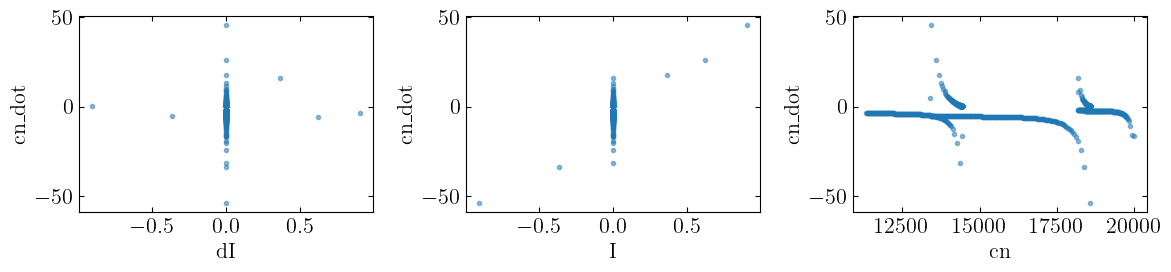

In [189]:
idx=4

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

indices = np.argsort(dI_test[idx, :, 0])

axes[0].plot((dI_test[idx, :, 0]), cn_dot_test[idx, indices, 0], '.', alpha=0.5)
axes[0].set_xlabel('dI')
axes[0].set_ylabel('cn_dot')

axes[1].plot(np.sort(dI_test[idx, :, 0]), np.sort(cn_dot_test[idx, :, 0]), '.', alpha=0.5)
axes[1].set_xlabel('I')
axes[1].set_ylabel('cn_dot')

axes[2].plot(cn_test[idx, :, 0], cn_dot_test[idx, :, 0], '.', alpha=0.5)
axes[2].set_xlabel('cn')
axes[2].set_ylabel('cn_dot')

plt.tight_layout()

In [300]:
''' Mk 1 '''
class Net(nn.Module):
    def __init__(self, input_size=4, hidden_size=128):
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 2)   # [cn_dot, cp_dot]
        )
    
    def forward(self, x):
        x = self.net(x)
        return x

''' Mk 2: LSTM '''
# class Net(nn.Module):
#     def __init__(self, input_size=4, hidden_size=64):
#         super(Net, self).__init__()
#         self.net = nn.LSTM(input_size, hidden_size, num_layers=2, batch_first=True)
#         self.head = nn.Linear(hidden_size, 2)   # [cn_dot, cp_dot]
    
#     def forward(self, x):
#         out, _ = self.net(x)
#         x = self.head(out)
#         return x
    
''' Mk3: GRU '''
# class Net(nn.Module):
#     def __init__(self, input_size=4, hidden_size=64, num_layers=2):
#         super(Net, self).__init__()
#         self.net = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
#         self.head = nn.Linear(hidden_size, 2)   # [cn_dot, cp_dot]
    
#     def forward(self, x):
#         out, _ = self.net(x)
#         x = self.head(out)
#         return x
    
model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [301]:
def masked_mse(pred, target, mask):
    # pred, target: (N, 2)   mask: (N)
    err = (pred - target) ** 2    # (B*T, 2)
    m = mask.unsqueeze(-1)        # (B*T, 1) — broadcasts over 2 outputs
    return (err * m).sum() / (m.sum() * 2)

''' Mk 1: Standard training '''
def training(epochs=30):
    history = {"loss": []}
    for ep in range(epochs):
        model.train()
        ep_loss = 0.0

        for x_b, y_b, mask_b in train_loader_flat:
            # print('batch shapes:', x_b.shape, y_b.shape, mask_b.shape)
            pred = model(x_b)   # [B*T, 2]
            loss = masked_mse(pred, y_b, mask_b)
            # print('pred shapes:', pred.shape)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            ep_loss += loss.item()

        last = ep_loss / len(train_loader_flat)  # Average loss per batch
        history["loss"].append(last)
        print(f"Epoch {ep+1} | loss {last:.3e}")

    return history

''' Mk 2: Rollout loss if time dependent (B, T) '''
def rollout_loss(model, x_b, y_b, mask_b, n_steps=10):
    """
    Unroll model for n_steps using its own predictions as next input.
    x_b: (B, T, 4),  y_b: (B, T, 2),  mask_b: (B, T)
    """
    B, T, _ = x_b.shape
    loss = 0.0

    # Ground truth
    cn_gt = x_b[:, :, 2:3]         # (B, T, 1)
    cp_gt = x_b[:, :, 3:4]

    # Start at random point in time
    s = torch.randint(0, T - n_steps - 1, (1,)).item()  # Random start index for rollout

    # Use ground truth I and dI, but propagate c from model output
    cn_cur = x_b[:, s, 2:3]        # initial cn (normalised)
    cp_cur = x_b[:, s, 3:4]        # initial cp (normalised)

    mean_cn, std_cn = stats["cn"][0], stats["cn"][1]
    mean_cp, std_cp = stats["cp"][0], stats["cp"][1]
    mean_dcn, std_dcn = stats["cn_dot"][0], stats["cn_dot"][1]
    mean_dcp, std_dcp = stats["cp_dot"][0], stats["cp_dot"][1]

    for t in range(n_steps):
        I_t = x_b[:, s + t, 0:1]
        dI_t = x_b[:, s + t, 1:2]
        # print('I_t shape:', I_t.shape, 'dI_t shape:', dI_t.shape, 'cn_cur shape:', cn_cur.shape, 'cp_cur shape:', cp_cur.shape)
        x_t = torch.cat([I_t, dI_t, cn_cur, cp_cur], dim=-1)                     # (B, 4)
        # print('x_t shape:', x_t.shape)
        pred = model(x_t)              # (B, 2)
        # print(pred[:, 0:1].shape)

        # loss on this step
        # step_mask = mask_b[:, t].unsqueeze(-1)      # (B, 1)
        # loss += ((pred - y_b[:, t, :]) ** 2 * step_mask).sum() / (step_mask.sum() * 2 + 1e-8)

        # Euler in physical space — pure torch, keeps gradients
        cn_phys = cn_cur * std_cn + mean_cn
        cp_phys = cp_cur * std_cp + mean_cp
        dc_n = pred[:, 0:1] * std_dcn + mean_dcn
        dc_p = pred[:, 1:2] * std_dcp + mean_dcp

        cn_phys_next = cn_phys + dc_n * DT
        cp_phys_next = cp_phys + dc_p * DT

        cn_cur = (cn_phys_next - mean_cn) / std_cn
        cp_cur = (cp_phys_next - mean_cp) / std_cp

        # Masked MSE
        step_mask = mask_b[:, s+t+1].unsqueeze(-1)     # (B, 1)
        cn_err = (cn_cur - cn_gt[:, s+t+1, :]) ** 2    # (B, 1)
        cp_err = (cp_cur - cp_gt[:, s+t+1, :]) ** 2    # (B, 1)
        loss += ((cn_err + cp_err) * step_mask).sum() / (step_mask.sum())
 
    return loss / min(T - 1, n_steps)


def training_rollout(epochs=100, n_steps_start=10, n_steps_end=500, lam_normal_mse=0.1):
    """
    Start with 1-step rollout loss, gradually increase to n_steps_end.
    """
    history = {"loss": []}
    # scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

    for ep in range(epochs):
        model.train()
        # linearly increase rollout horizon over training
        n_steps = int(n_steps_start + (n_steps_end - n_steps_start) * ep / max(epochs - 1, 1))
        ep_loss = 0.0

        for x_b, y_b, mask_b in train_loader_batch:
            loss = rollout_loss(model, x_b, y_b, mask_b, n_steps=n_steps)
            loss += masked_mse(model(x_b.reshape(-1, 4)), y_b.reshape(-1, 2), mask_b.reshape(-1)) * lam_normal_mse  # Auxiliary one-step loss
            optimizer.zero_grad()
            loss.backward()
            # nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            ep_loss += loss.item()

        ep_loss /= len(train_loader_batch)  # Average loss per batch
        # scheduler.step(ep_loss)
        history["loss"].append(ep_loss)

        print(f"Epoch {ep+1:3d} | n_steps={n_steps:3d} | loss {ep_loss:.3e}")

        # for name, param in model.named_parameters():
        #     if param.grad is not None:
        #         print(f"{name}: grad norm = {param.grad.norm():.3e}")

    return history

''' Mk 3 '''
def rollout_loss_fixed(model, x_b, y_b, mask_b, n_steps=10):
    B, T, _ = x_b.shape
    loss = 0.0
    count = 0

    cn_gt = x_b[:, :, 2:3]
    cp_gt = x_b[:, :, 3:4]

    mean_cn, std_cn = stats["cn"][0], stats["cn"][1]
    mean_cp, std_cp = stats["cp"][0], stats["cp"][1]
    mean_dcn, std_dcn = stats["cn_dot"][0], stats["cn_dot"][1]
    mean_dcp, std_dcp = stats["cp_dot"][0], stats["cp_dot"][1]

    # FIX 1: sweep ALL valid start points, not just one random one
    # (or at least several random ones)
    n_starts = 4
    starts = torch.randint(0, T - n_steps, (n_starts,))

    for s in starts:
        cn_cur = x_b[:, s, 2:3].clone()
        cp_cur = x_b[:, s, 3:4].clone()

        for t in range(n_steps):
            I_t  = x_b[:, s + t, 0:1]
            dI_t = x_b[:, s + t, 1:2]
            x_t  = torch.cat([I_t, dI_t, cn_cur, cp_cur], dim=-1)
            pred = model(x_t)

            cn_phys = cn_cur * std_cn + mean_cn
            cp_phys = cp_cur * std_cp + mean_cp
            dc_n = pred[:, 0:1] * std_dcn + mean_dcn
            dc_p = pred[:, 1:2] * std_dcp + mean_dcp

            cn_cur = (cn_phys + dc_n * DT - mean_cn) / std_cn
            cp_cur = (cp_phys + dc_p * DT - mean_cp) / std_cp

            step_mask = mask_b[:, s + t + 1].unsqueeze(-1)
            cn_err = (cn_cur - cn_gt[:, s + t + 1, :]) ** 2
            cp_err = (cp_cur - cp_gt[:, s + t + 1, :]) ** 2
            denom = step_mask.sum() + 1e-8
            loss += ((cn_err + cp_err) * step_mask).sum() / denom
            count += 1

    return loss / max(count, 1)


def training_rollout_fixed(epochs=100, n_steps_start=2, n_steps_end=50, lam=1.0):
    """
    FIX 2: cap n_steps_end much lower (50 not 500)
    FIX 3: balance lambda so rollout & 1-step losses are similar scale
    """
    history = {"loss": [], "onestep": [], "rollout": []}
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    for ep in range(epochs):
        model.train()
        # FIX 4: slower curriculum — sqrt schedule instead of linear
        frac = (ep / max(epochs - 1, 1)) ** 0.5
        n_steps = int(n_steps_start + (n_steps_end - n_steps_start) * frac)
        ep_loss = ep_r = ep_1 = 0.0

        for x_b, y_b, mask_b in train_loader_batch:
            r_loss = rollout_loss_fixed(model, x_b, y_b, mask_b, n_steps=n_steps)
            o_loss = masked_mse(model(x_b.reshape(-1, 4)), y_b.reshape(-1, 2), mask_b.reshape(-1))
            loss = r_loss + lam * o_loss

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # FIX 5: grad clip
            optimizer.step()

            ep_loss += loss.item()
            ep_r    += r_loss.item()
            ep_1    += o_loss.item()

        n = len(train_loader_batch)
        history["loss"].append(ep_loss / n)
        history["rollout"].append(ep_r / n)
        history["onestep"].append(ep_1 / n)
        scheduler.step()
        print(f"Ep {ep+1:3d} | n_steps={n_steps} | total={ep_loss/n:.3e} | rollout={ep_r/n:.3e} | 1step={ep_1/n:.3e}")

    return history

# history = training(epochs=50)
history_rollout = training_rollout_fixed(epochs=50, n_steps_start=10, n_steps_end=T-1, lam=1)

Ep   1 | n_steps=10 | total=8.861e-01 | rollout=1.821e-03 | 1step=8.843e-01
Ep   2 | n_steps=151 | total=7.357e-01 | rollout=8.202e-02 | 1step=6.536e-01
Ep   3 | n_steps=209 | total=5.341e-01 | rollout=6.816e-02 | 1step=4.659e-01
Ep   4 | n_steps=254 | total=3.823e-01 | rollout=4.939e-02 | 1step=3.329e-01
Ep   5 | n_steps=292 | total=3.673e-01 | rollout=3.781e-02 | 1step=3.295e-01
Ep   6 | n_steps=325 | total=3.931e-01 | rollout=4.640e-02 | 1step=3.467e-01
Ep   7 | n_steps=356 | total=3.636e-01 | rollout=3.612e-02 | 1step=3.275e-01
Ep   8 | n_steps=383 | total=3.476e-01 | rollout=3.334e-02 | 1step=3.143e-01
Ep   9 | n_steps=409 | total=3.413e-01 | rollout=2.838e-02 | 1step=3.130e-01
Ep  10 | n_steps=433 | total=3.354e-01 | rollout=2.847e-02 | 1step=3.069e-01
Ep  11 | n_steps=456 | total=3.414e-01 | rollout=2.818e-02 | 1step=3.133e-01
Ep  12 | n_steps=478 | total=3.349e-01 | rollout=2.772e-02 | 1step=3.072e-01
Ep  13 | n_steps=499 | total=3.366e-01 | rollout=2.910e-02 | 1step=3.075e-01


0.2428475059568882
0.3133399933576584


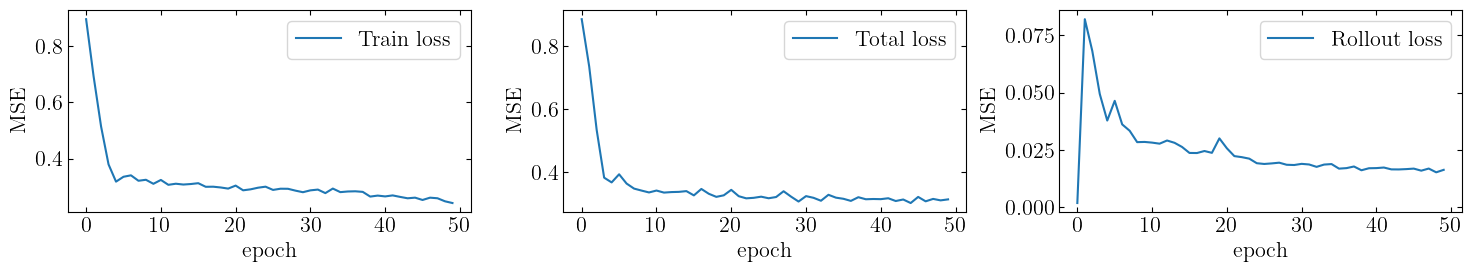

In [306]:
print(history['loss'][-1])
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 3))
ax1.plot(history["loss"], label="Train loss")
# ax1.set_yscale("log")
ax1.set_xlabel("epoch")
ax1.set_ylabel("MSE")
ax1.legend()

# Plot the last few epochs of both losses for comparison
print(history_rollout['loss'][-1])
ax2.plot(history_rollout["loss"], label="Total loss")
ax2.set_xlabel("epoch")
ax2.set_ylabel("MSE")
ax2.legend()

ax3.plot(history_rollout["rollout"], label="Rollout loss")
ax3.set_xlabel("epoch")
ax3.set_ylabel("MSE")
ax3.legend()
plt.tight_layout()

In [307]:
def rollout(idx=0, on_train=False):
    if on_train:
        cn_true = cn_train
        cp_true = cp_train
        I_true = I_train
        dI_true = dI_train
    else:
        cn_true = cn_test
        cp_true = cp_test
        I_true = I_test
        dI_true = dI_test

    model.eval()

    # Initial un-normalized values for the chosen trajectory
    c0_n = cn_true[idx, 0, 0]
    c0_p = cp_true[idx, 0, 0]

    cn_min = cn_true[idx].min()  # For explicit stopper criterion

    cn_traj = np.zeros(T, dtype=np.float32)
    cp_traj = np.zeros(T, dtype=np.float32)
    cn_dot_traj = np.zeros(T, dtype=np.float32)
    cp_dot_traj = np.zeros(T, dtype=np.float32)
    cn_traj[0] = c0_n
    cp_traj[0] = c0_p

    steps_run = 1

    with torch.no_grad():
        for t in range(T - 1):
            # build normalised input for this step
            I_val  = float(I_true[idx, t, 0])
            dI_val = float(dI_true[idx, t, 0])
            
            x_t = np.array([[
                transform(np.array([[[I_val]]]),  "I")[0,0,0],  # True
                transform(np.array([[[dI_val]]]), "dI")[0,0,0], # True
                transform(np.array([[[cn_traj[t]]]]), "cn")[0,0,0],     # Predicted
                transform(np.array([[[cp_traj[t]]]]), "cp")[0,0,0],]], dtype=np.float32)      # Predicted                  # (1, 4)
            # print('Input x_t shape:', x_t.shape)
            # Predict on initial state (1, 4)
            pred = model(torch.tensor(x_t))              # (1, 2)
            # print(pred)
            dc_n = inverse_transform(pred[0,0].numpy().reshape(1,1,1), "cn_dot")[0,0,0]
            dc_p = inverse_transform(pred[0,1].numpy().reshape(1,1,1), "cp_dot")[0,0,0]

            cn_traj[t+1] = cn_traj[t] + dc_n * DT
            cp_traj[t+1] = cp_traj[t] + dc_p * DT
            cn_dot_traj[t] = dc_n
            cp_dot_traj[t] = dc_p

            steps_run += 1

            # Stop if concentration goes below a threshold
            if cn_traj[t+1] < cn_min:  # Depleated battery
                break

    return cn_traj, cp_traj, cn_dot_traj, cp_dot_traj, steps_run

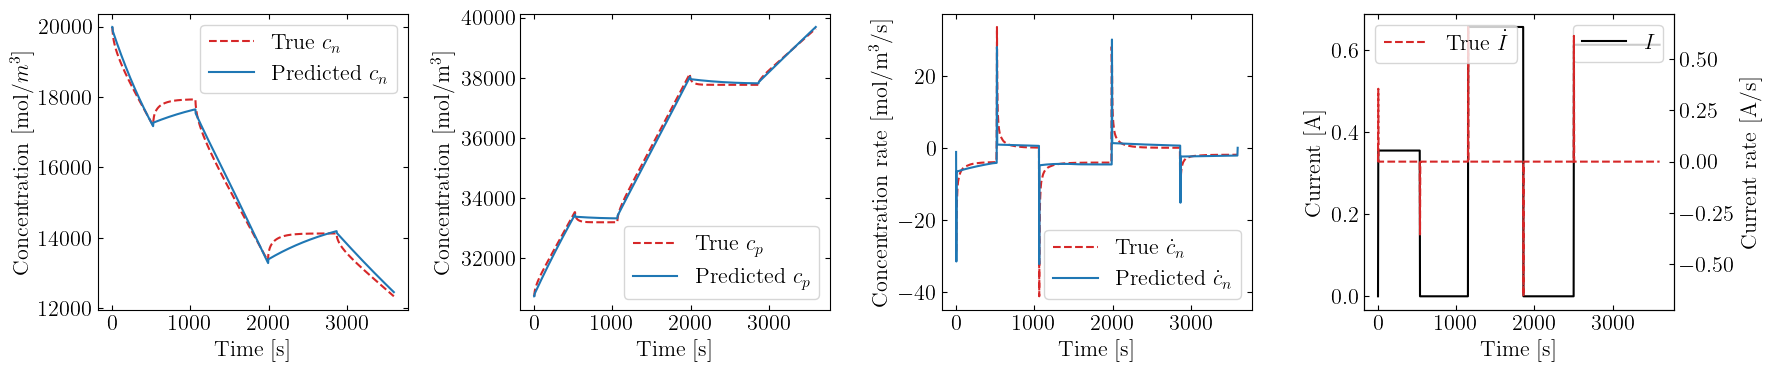

In [308]:
def plot_rollout(idx=0, on_train=False):
    if on_train:
        cn_true = cn_train
        cp_true = cp_train
        cn_dot_true = cn_dot_train
        cp_dot_true = cp_dot_train
    else:
        cn_true = cn_test
        cp_true = cp_test
        cn_dot_true = cn_dot_test
        cp_dot_true = cp_dot_test
    
    cn_euler, cp_euler, cn_dot_euler, cp_dot_euler, steps_run = rollout(idx, on_train=on_train)

    # Ground truth valid length
    n_gt = int(mask_train_plot[idx].sum())          # number of valid GT steps
    n_nn = steps_run                          # number of NN steps before stopping

    t_gt = np.arange(n_gt) * DT             # physical time axis for GT
    t_nn = np.arange(n_nn) * DT             # physical time axis for NN

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    # print('Valid lengths:', n_gt, n_nn)
    # print('Shapes:', cn_train.shape, cp_train.shape, cn_dot_train.shape, cp_dot_train.shape, I_train.shape, dI_train.shape)
    # print(cn_train[0, n_gt:, 0])

    # --- cn ---
    axes[0].plot(t_gt, cn_true[idx, :n_gt, 0], color="tab:red", linestyle="dashed", label="True $c_n$")
    axes[0].plot(t_nn, cn_euler[:n_nn], color="tab:blue", label="Predicted $c_n$")
    axes[0].set_xlabel("Time [s]")
    axes[0].set_ylabel(r"Concentration [mol/$m^3$]")
    axes[0].legend()

    # --- cp ---
    axes[1].plot(t_gt, cp_true[idx, :n_gt, 0], color="tab:red", linestyle="dashed", label="True $c_p$")
    axes[1].plot(t_nn, cp_euler[:n_nn], color="tab:blue", label="Predicted $c_p$")
    axes[1].set_xlabel("Time [s]")
    axes[1].set_ylabel(r"Concentration [mol/m$^3$]")
    axes[1].legend()

    # --- cn_dot ---
    axes[2].plot(t_gt, cn_dot_true[idx, :n_gt, 0], color="tab:red", linestyle="dashed", label="True $\\dot{c}_n$")
    axes[2].plot(t_nn, cn_dot_euler[:n_nn], color="tab:blue", label="Predicted $\\dot{c}_n$")
    axes[2].set_xlabel("Time [s]")
    axes[2].set_ylabel(r"Concentration rate [mol/m$^3$/s]")
    axes[2].legend()
    
    # --- current ---
    axes[3].plot(t_gt, I_train[idx, :n_gt, 0], color="black", label="$I$")
    axes[3].set_xlabel("Time [s]")
    axes[3].set_ylabel("Current [A]")
    axes[3].legend(loc='upper right')


    # --- dI ---
    axes3_ = axes[3].twinx()
    axes3_.plot(t_gt, dI_train[idx, :n_gt, 0], color="tab:red", linestyle="dashed", label="True $\\dot{I}$")
    axes3_.set_ylabel(r"Current rate [A/s]")
    axes3_.legend(loc='upper left')

    plt.tight_layout()

plot_rollout(idx=0, on_train=False)

0.03164397951584013


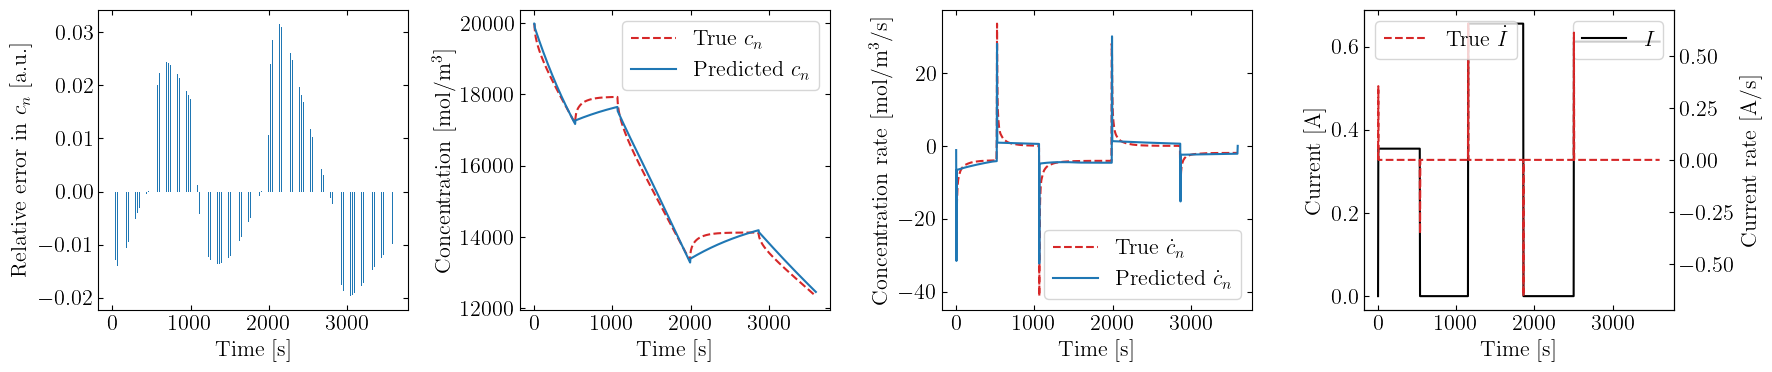

In [ ]:
def plot_rollout(idx=0, on_train=False):
    if on_train:
        cn_true = cn_train
        cp_true = cp_train
        cn_dot_true = cn_dot_train
        cp_dot_true = cp_dot_train
    else:
        cn_true = cn_test
        cp_true = cp_test
        cn_dot_true = cn_dot_test
        cp_dot_true = cp_dot_test
    
    cn_euler, cp_euler, cn_dot_euler, cp_dot_euler, steps_run = rollout(idx, on_train=on_train)

    # Ground truth valid length
    n_gt = int(mask_train_plot[idx].sum())          # number of valid GT steps
    n_nn = steps_run                          # number of NN steps before stopping

    t_gt = np.arange(n_gt) * DT             # physical time axis for GT
    t_nn = np.arange(n_nn) * DT             # physical time axis for NN

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    # print('Valid lengths:', n_gt, n_nn)
    # print('Shapes:', cn_train.shape, cp_train.shape, cn_dot_train.shape, cp_dot_train.shape, I_train.shape, dI_train.shape)
    # print(cn_train[0, n_gt:, 0])

    cn_err = (cn_true[idx, :n_nn, 0] - cn_euler[:n_nn]) / (cn_true[idx, :n_nn, 0])
    print(np.max(np.abs(cn_err)))
    # --- cn err ---
    axes[0].bar(t_nn, cn_err, color="tab:blue")
    axes[0].set_xlabel("Time [s]")
    axes[0].set_ylabel("Relative error in $c_n$ [a.u.]")
    # axes[0].legend()

    # --- cp ---
    axes[1].plot(t_gt, cn_true[idx, :n_gt, 0], color="tab:red", linestyle="dashed", label="True $c_n$")
    axes[1].plot(t_nn, cn_euler[:n_nn], color="tab:blue", label="Predicted $c_n$")
    axes[1].set_xlabel("Time [s]")
    axes[1].set_ylabel(r"Concentration [mol/m$^3$]")
    axes[1].legend()

    # --- cn_dot ---
    axes[2].plot(t_gt, cn_dot_true[idx, :n_gt, 0], color="tab:red", linestyle="dashed", label="True $\\dot{c}_n$")
    axes[2].plot(t_nn, cn_dot_euler[:n_nn], color="tab:blue", label="Predicted $\\dot{c}_n$")
    axes[2].set_xlabel("Time [s]")
    axes[2].set_ylabel(r"Concentration rate [mol/m$^3$/s]")
    axes[2].legend()
    
    # --- current ---
    axes[3].plot(t_gt, I_train[idx, :n_gt, 0], color="black", label="$I$")
    axes[3].set_xlabel("Time [s]")
    axes[3].set_ylabel("Current [A]")
    axes[3].legend(loc='upper right')


    # --- dI ---
    axes3_ = axes[3].twinx()
    axes3_.plot(t_gt, dI_train[idx, :n_gt, 0], color="tab:red", linestyle="dashed", label="True $\\dot{I}$")
    axes3_.set_ylabel(r"Current rate [A/s]")
    axes3_.legend(loc='upper left')

    plt.tight_layout()
    # plt.savefig('figs/pulse_w_rollout_50eps_10to999_steps.pdf')

plot_rollout(idx=0, on_train=False)